# Waste Sorting with a Pretrained CNN

Classifies household waste photos into 12 categories (cardboard, brown/green/white glass, metal, paper, plastic, biological, battery, clothes, shoes, trash) using a **MobileNetV2** backbone pretrained on ImageNet.

Pipeline: EDA on class counts/samples &rarr; stratified train/val/test split from the folder structure &rarr; `tf.data` preprocessing pipeline matched to MobileNetV2 &rarr; two-phase transfer learning (frozen head, then fine-tuning) &rarr; per-class precision/recall/F1 + confusion matrix on a held-out test set &rarr; export model for the Streamlit app.

Dataset: [Kaggle - Garbage Classification (12 classes)](https://www.kaggle.com/datasets/mostafaabla/garbage-classification), ~15.5k images, downloaded locally to `../Data/extracted/garbage_classification`.

**Environment note:** this machine has no GPU (native Windows + TensorFlow 2.x has no GPU support outside WSL2), so image size, batch size, and epoch counts below are chosen to keep CPU training times reasonable rather than to chase maximum accuracy.

In [1]:
import os
import json
import random
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, MobileNetV2

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPUs visible:", tf.config.list_physical_devices("GPU"))

DATA_DIR = pathlib.Path("../Data/extracted/garbage_classification")
assert DATA_DIR.exists(), f"Dataset folder not found at {DATA_DIR.resolve()}"
CLASS_NAMES = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
print(f"{len(CLASS_NAMES)} classes:", CLASS_NAMES)

TensorFlow: 2.21.0


GPUs visible: []
12 classes: ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']


## 1. Explore the raw data

Class counts first (the brief warns the classes are not evenly sized), then a grid of sample images per class so we know what we're working with before doing any preprocessing.

Total images: 15515
label
battery         945
biological      985
brown-glass     607
cardboard       891
clothes        5325
green-glass     629
metal           769
paper          1050
plastic         865
shoes          1977
trash           697
white-glass     775
Name: count, dtype: int64


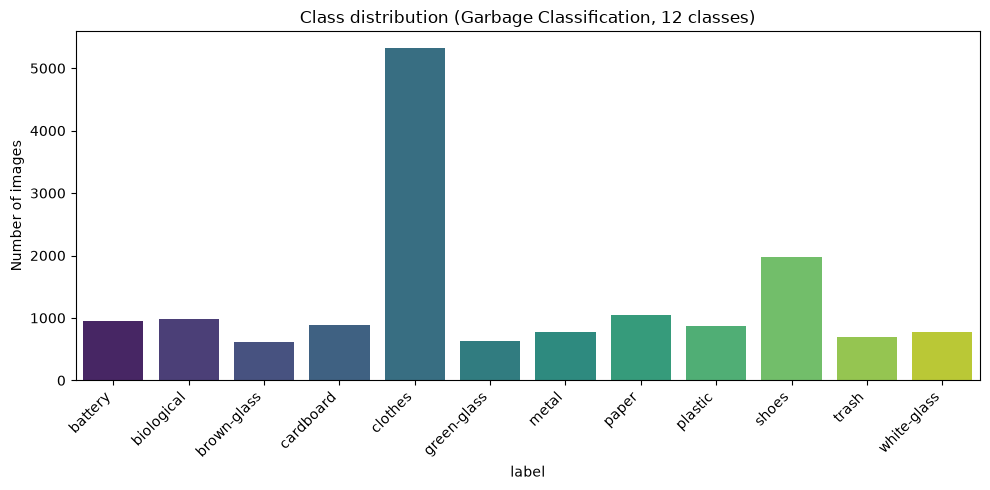


Largest class: clothes (5325) | Smallest class: brown-glass (607) | Imbalance ratio: 8.8x


In [2]:
# Build a full (filepath, label) table by scanning the per-class folders.
records = []
for cls in CLASS_NAMES:
    for fp in (DATA_DIR / cls).glob("*.jpg"):
        records.append({"filepath": str(fp), "label": cls})

df = pd.DataFrame(records)
print("Total images:", len(df))

counts = df["label"].value_counts().reindex(CLASS_NAMES)
print(counts)

plt.figure(figsize=(10, 5))
sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette="viridis", legend=False)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of images")
plt.title("Class distribution (Garbage Classification, 12 classes)")
plt.tight_layout()
plt.show()

print(f"\nLargest class: {counts.idxmax()} ({counts.max()}) | "
      f"Smallest class: {counts.idxmin()} ({counts.min()}) | "
      f"Imbalance ratio: {counts.max() / counts.min():.1f}x")

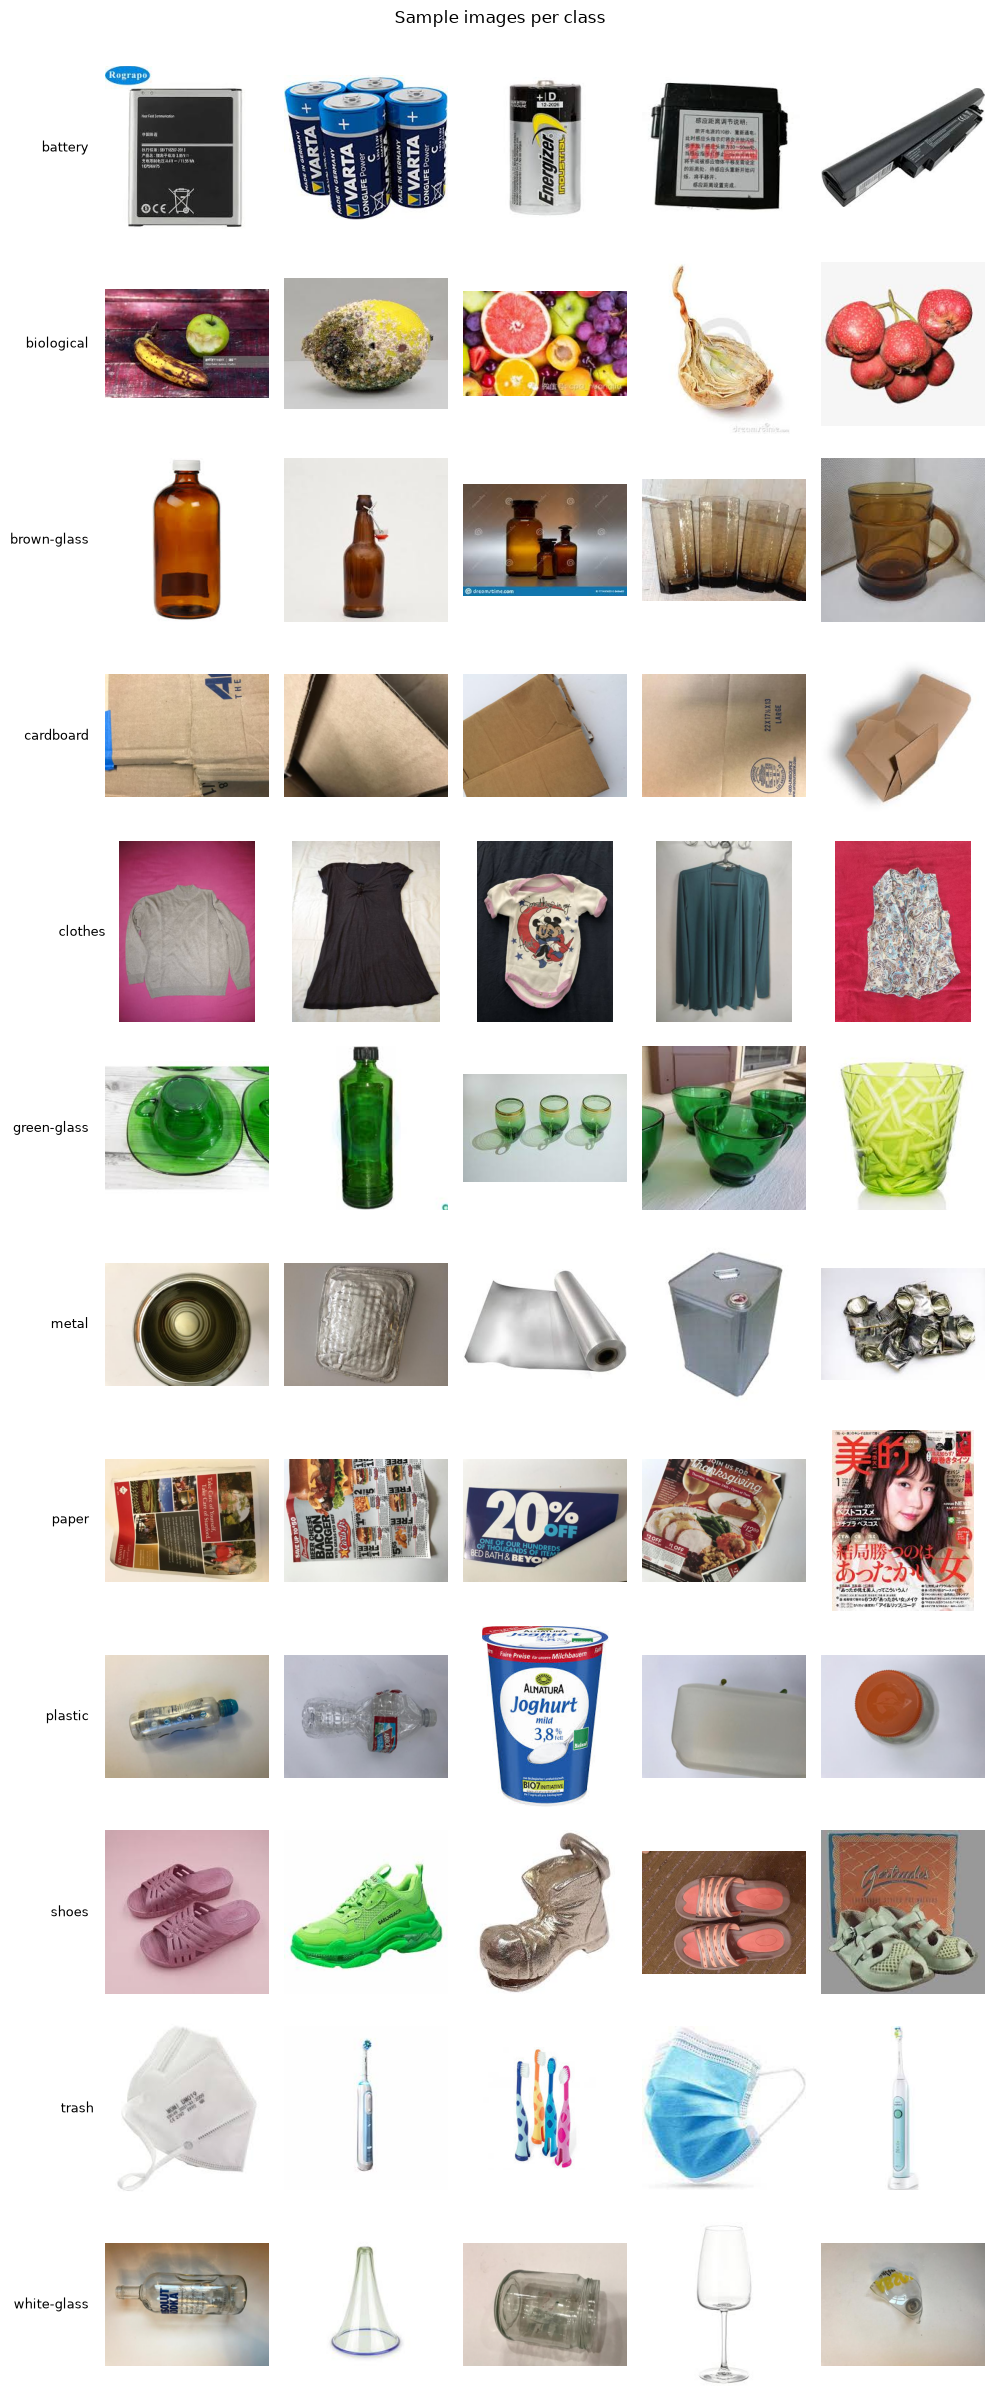

In [3]:
# A handful of sample images per class, so we can already see which categories
# look visually similar (paper vs. cardboard, the three glass colors, etc.)
n_samples = 5
fig, axes = plt.subplots(len(CLASS_NAMES), n_samples, figsize=(n_samples * 2, len(CLASS_NAMES) * 2))

rng = random.Random(SEED)
for row, cls in enumerate(CLASS_NAMES):
    sample_paths = rng.sample(list((DATA_DIR / cls).glob("*.jpg")), n_samples)
    for col, fp in enumerate(sample_paths):
        img = Image.open(fp)
        axes[row, col].imshow(img)
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(cls)
            axes[row, col].text(-0.1, 0.5, cls, transform=axes[row, col].transAxes,
                                 ha="right", va="center", fontsize=9, rotation=0)

plt.suptitle("Sample images per class", y=1.0)
plt.tight_layout()
plt.show()

## 2. Train / validation / test split

Split **before** touching a model, and stratify by class so the imbalance is preserved (not amplified) in every split: 70% train / 15% validation / 15% test.

In [4]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["label"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")

split_counts = pd.DataFrame({
    "train": train_df["label"].value_counts(),
    "val": val_df["label"].value_counts(),
    "test": test_df["label"].value_counts(),
}).reindex(CLASS_NAMES)
split_counts

Train: 10860  Val: 2327  Test: 2328


,train,val,test
label,,,
battery,661,142,142
biological,689,148,148
brown-glass,425,91,91
cardboard,624,133,134
clothes,3727,799,799
green-glass,440,95,94
metal,538,116,115
paper,735,157,158
plastic,606,129,130


## 3. Preprocessing pipeline

Backbone choice: **MobileNetV2**. It's the lightest of the common transfer-learning backbones (~3.4M params vs. ~24M for ResNet50), which matters a lot here since this machine trains on CPU only — MobileNetV2's depthwise-separable convolutions are noticeably cheaper per forward/backward pass, and its accuracy on mid-sized image classification tasks is competitive with the heavier backbones.

Images are resized to MobileNetV2's expected `160x160x3` input and run through `mobilenet_v2.preprocess_input` (scales pixels to `[-1, 1]`, the exact normalization the ImageNet weights were trained with) rather than a generic `/255.` normalization.

Everything is built as a `tf.data` pipeline reading straight from disk (no in-memory caching of the whole dataset — this machine is memory-constrained), with light augmentation applied to the training split only.

In [5]:
IMG_SIZE = 160
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

label_to_index = {name: i for i, name in enumerate(CLASS_NAMES)}

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="augmentation")


def load_and_preprocess(filepath, label, augment):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    if augment:
        image = data_augmentation(image)
    image = preprocess_input(image)
    return image, label


def make_dataset(dataframe, augment, shuffle):
    filepaths = dataframe["filepath"].values
    labels = dataframe["label"].map(label_to_index).values
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(lambda fp, lb: load_and_preprocess(fp, lb, augment), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds


train_ds = make_dataset(train_df, augment=True, shuffle=True)
val_ds = make_dataset(val_df, augment=False, shuffle=False)
test_ds = make_dataset(test_df, augment=False, shuffle=False)

# Sanity check: pull one batch and confirm shapes / value range.
images, labels = next(iter(train_ds))
print("Batch images shape:", images.shape, "| labels shape:", labels.shape)
print("Pixel value range after preprocess_input:", float(tf.reduce_min(images)), "to", float(tf.reduce_max(images)))

Batch images shape: (32, 160, 160, 3) | labels shape: (32,)
Pixel value range after preprocess_input: -1.0 to 1.0


## 4. Class weights

`clothes` has ~9x as many images as `brown-glass`. Rather than resampling the dataset, we pass per-class weights into `model.fit` so the loss penalizes mistakes on minority classes more — cheaper than oversampling and works well with `tf.data` pipelines.

In [6]:
train_labels_idx = train_df["label"].map(label_to_index).values
class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(CLASS_NAMES)),
    y=train_labels_idx,
)
class_weight = {i: w for i, w in enumerate(class_weight_values)}

for name, idx in label_to_index.items():
    print(f"{name:12s} weight={class_weight[idx]:.3f}")

battery      weight=1.369
biological   weight=1.313
brown-glass  weight=2.129
cardboard    weight=1.450
clothes      weight=0.243
green-glass  weight=2.057
metal        weight=1.682
paper        weight=1.231
plastic      weight=1.493
shoes        weight=0.654
trash        weight=1.855
white-glass  weight=1.667


## 5. Phase 1 — freeze the backbone, train the classification head

Build `MobileNetV2(weights="imagenet", include_top=False)` as a frozen feature extractor, pool its output, and put a small dense head on top. Only the head trains in this phase — the backbone's ImageNet features are used as-is.

In [7]:
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet",
)
base_model.trainable = False
print("Backbone layers:", len(base_model.layers))

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(len(CLASS_NAMES), activation="softmax")(x)

model = keras.Model(inputs, outputs, name="waste_classifier")
model.summary()

Backbone layers: 154


Model: "waste_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,500 (9.24 MB)

 Trainable params: 165,516 (646.55 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
PHASE1_EPOCHS = 10

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

phase1_callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
]

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE1_EPOCHS,
    class_weight=class_weight,
    callbacks=phase1_callbacks,
)

Epoch 1/10


C:\Users\Noureldin Bassem\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


  1/340 ━━━━━━━━━━━━━━━━━━━━ 17:08 3s/step - accuracy: 0.1562 - loss: 3.0915

  2/340 ━━━━━━━━━━━━━━━━━━━━ 1:09 205ms/step - accuracy: 0.1250 - loss: 3.0324

  3/340 ━━━━━━━━━━━━━━━━━━━━ 1:09 205ms/step - accuracy: 0.1354 - loss: 3.0658

...

336/340 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.9369 - loss: 0.2177

337/340 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.9368 - loss: 0.2186

338/340 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.9369 - loss: 0.2181

339/340 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.9369 - loss: 0.2183

340/340 ━━━━━━━━━━━━━━━━━━━━ 57s 167ms/step - accuracy: 0.9368 - loss: 0.2183 - val_accuracy: 0.9351 - val_loss: 0.2158 - learning_rate: 0.0010


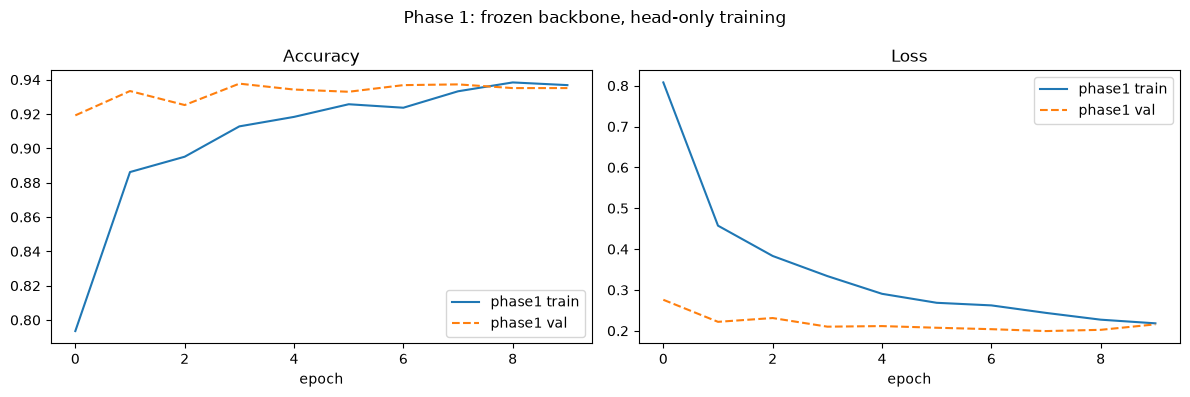

In [9]:
def plot_history(hist_dicts, labels, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for hist, lbl in zip(hist_dicts, labels):
        axes[0].plot(hist["accuracy"], label=f"{lbl} train")
        axes[0].plot(hist["val_accuracy"], label=f"{lbl} val", linestyle="--")
        axes[1].plot(hist["loss"], label=f"{lbl} train")
        axes[1].plot(hist["val_loss"], label=f"{lbl} val", linestyle="--")
    axes[0].set_title("Accuracy"); axes[0].set_xlabel("epoch"); axes[0].legend()
    axes[1].set_title("Loss"); axes[1].set_xlabel("epoch"); axes[1].legend()
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_history([history1.history], ["phase1"], "Phase 1: frozen backbone, head-only training")

## 6. Phase 2 — unfreeze and fine-tune

MobileNetV2's early layers learn generic, low-level features (edges, colors, textures) that transfer to almost any image task, while its later layers encode more dataset-specific, higher-level features. We unfreeze the **last ~30% of the backbone's layers** (roughly its last few inverted-residual blocks) and leave the rest frozen: this gives the model room to adapt its higher-level features to waste photos specifically (e.g. distinguishing the three glass colors) without disturbing the low-level features or overfitting the fairly small dataset by retraining the whole 3.4M-parameter backbone.

We recompile with a **much lower learning rate** (`1e-5`, 100x smaller than phase 1) — large updates at this stage would wreck the pretrained weights we're trying to gently adapt.

In [10]:
base_model.trainable = True

UNFREEZE_FRACTION = 0.30
n_layers = len(base_model.layers)
freeze_until = int(n_layers * (1 - UNFREEZE_FRACTION))

for layer in base_model.layers[:freeze_until]:
    layer.trainable = False
# BatchNorm layers should stay frozen even in the unfrozen tail — their running
# statistics were learned on ImageNet's scale of data and are easily destabilized
# by fine-tuning on a much smaller dataset with small batches.
for layer in base_model.layers[freeze_until:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

trainable_count = sum(l.trainable for l in base_model.layers)
print(f"Unfrozen {trainable_count}/{n_layers} backbone layers (last {UNFREEZE_FRACTION:.0%})")

PHASE2_EPOCHS = 10

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

phase2_callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7),
]

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE1_EPOCHS + PHASE2_EPOCHS,
    initial_epoch=len(history1.history["loss"]),
    class_weight=class_weight,
    callbacks=phase2_callbacks,
)

Unfrozen 31/154 backbone layers (last 30%)
Epoch 11/20


  1/340 ━━━━━━━━━━━━━━━━━━━━ 19:53 4s/step - accuracy: 0.9688 - loss: 0.1190

  2/340 ━━━━━━━━━━━━━━━━━━━━ 55s 165ms/step - accuracy: 0.9844 - loss: 0.0843

  3/340 ━━━━━━━━━━━━━━━━━━━━ 53s 159ms/step - accuracy: 0.9479 - loss: 0.1716

  4/340 ━━━━━━━━━━━━━━━━━━━━ 52s 157ms/step - accuracy: 0.9453 - loss: 0.1942

...

337/340 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.9618 - loss: 0.1358

338/340 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.9617 - loss: 0.1358

339/340 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.9617 - loss: 0.1361

340/340 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.9616 - loss: 0.1362

340/340 ━━━━━━━━━━━━━━━━━━━━ 68s 199ms/step - accuracy: 0.9616 - loss: 0.1362 - val_accuracy: 0.9484 - val_loss: 0.1766 - learning_rate: 5.0000e-06


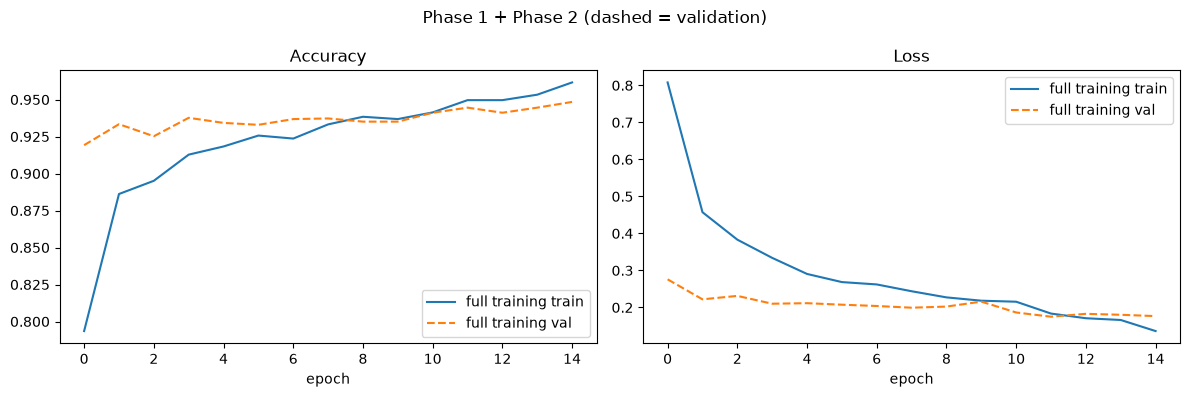

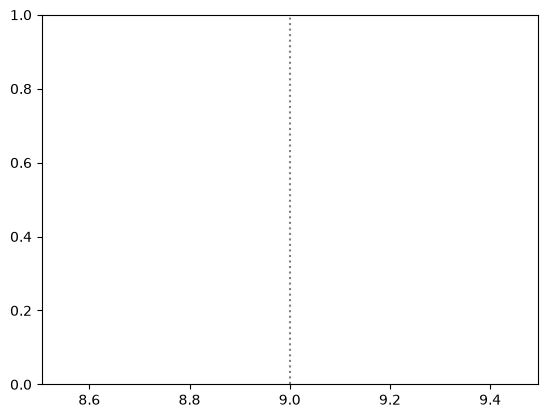

In [11]:
# Combine phase 1 + phase 2 histories into one continuous curve.
combined_history = {
    k: history1.history[k] + history2.history[k] for k in history1.history
}
plot_history([combined_history], ["full training"], "Phase 1 + Phase 2 (dashed = validation)")
plt.axvline(x=len(history1.history["loss"]) - 1, color="gray", linestyle=":", label="fine-tuning starts")

## 7. Evaluation on the held-out test set

The test set was split off before any model was built and never touched by training or validation. With 12 imbalanced classes, overall accuracy would hide poor performance on minority classes like `brown-glass`, so we look at per-class precision/recall/F1 and the full confusion matrix.

In [12]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.4f}")

y_true = test_df["label"].map(label_to_index).values
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nClassification report (test set):\n")
report_str = classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=3)
print(report_str)

report_dict = classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=3, output_dict=True)
report_df = pd.DataFrame(report_dict).T
report_df

 1/73 ━━━━━━━━━━━━━━━━━━━━ 1:06 925ms/step - accuracy: 0.8750 - loss: 0.2506

 2/73 ━━━━━━━━━━━━━━━━━━━━ 10s 147ms/step - accuracy: 0.8750 - loss: 0.2627 

 3/73 ━━━━━━━━━━━━━━━━━━━━ 10s 148ms/step - accuracy: 0.9167 - loss: 0.1978

 4/73 ━━━━━━━━━━━━━━━━━━━━ 10s 150ms/step - accuracy: 0.9141 - loss: 0.2095

 5/73 ━━━━━━━━━━━━━━━━━━━━ 10s 150ms/step - accuracy: 0.9250 - loss: 0.1923

...

72/73 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step

73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step

73/73 ━━━━━━━━━━━━━━━━━━━━ 11s 138ms/step



Classification report (test set):

              precision    recall  f1-score   support

     battery      0.963     0.908     0.935       142
  biological      0.958     0.932     0.945       148
 brown-glass      0.977     0.945     0.961        91
   cardboard      0.935     0.970     0.952       134
     clothes      0.987     0.979     0.983       799
 green-glass      0.957     0.947     0.952        94
       metal      0.781     0.930     0.849       115
       paper      0.940     0.892     0.916       158
     plastic      0.800     0.862     0.830       130
       shoes      0.948     0.980     0.964       297
       trash      0.942     0.942     0.942       104
 white-glass      0.900     0.776     0.833       116

    accuracy                          0.942      2328
   macro avg      0.924     0.922     0.922      2328
weighted avg      0.944     0.942     0.942      2328



,precision,recall,f1-score,support
battery,0.962687,0.908451,0.934783,142.00000
biological,0.958333,0.932432,0.945205,148.00000
brown-glass,0.977273,0.945055,0.960894,91.00000
cardboard,0.935252,0.970149,0.952381,134.00000
clothes,0.987374,0.978723,0.983030,799.00000
green-glass,0.956989,0.946809,0.951872,94.00000
metal,0.781022,0.930435,0.849206,115.00000
paper,0.940000,0.892405,0.915584,158.00000
plastic,0.800000,0.861538,0.829630,130.00000
shoes,0.947883,0.979798,0.963576,297.00000


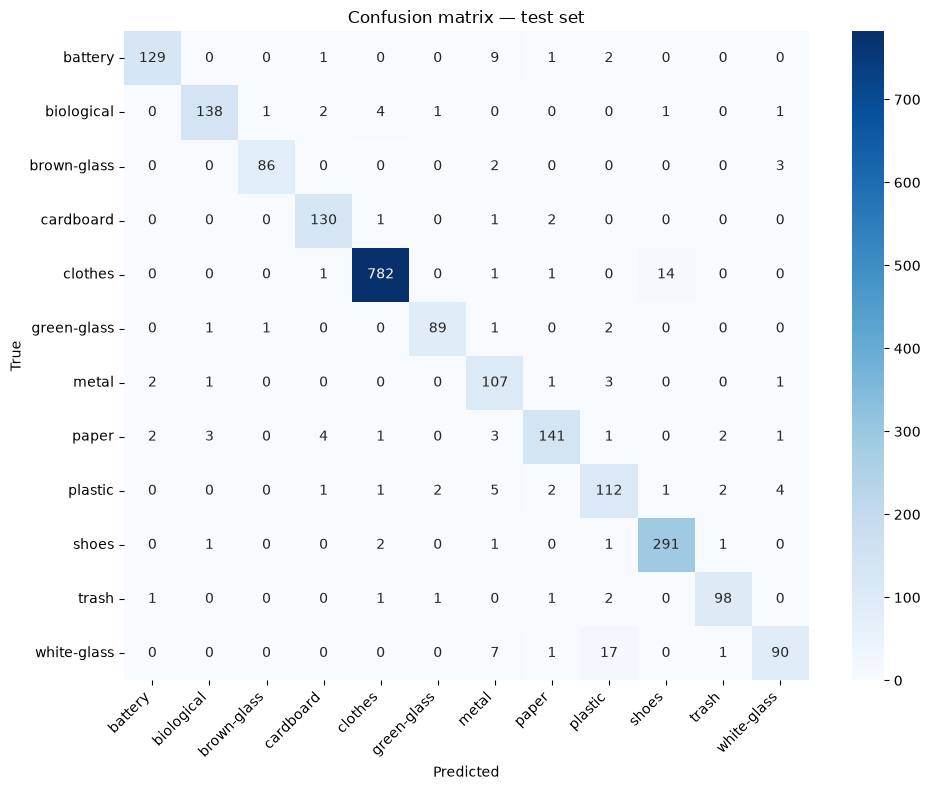

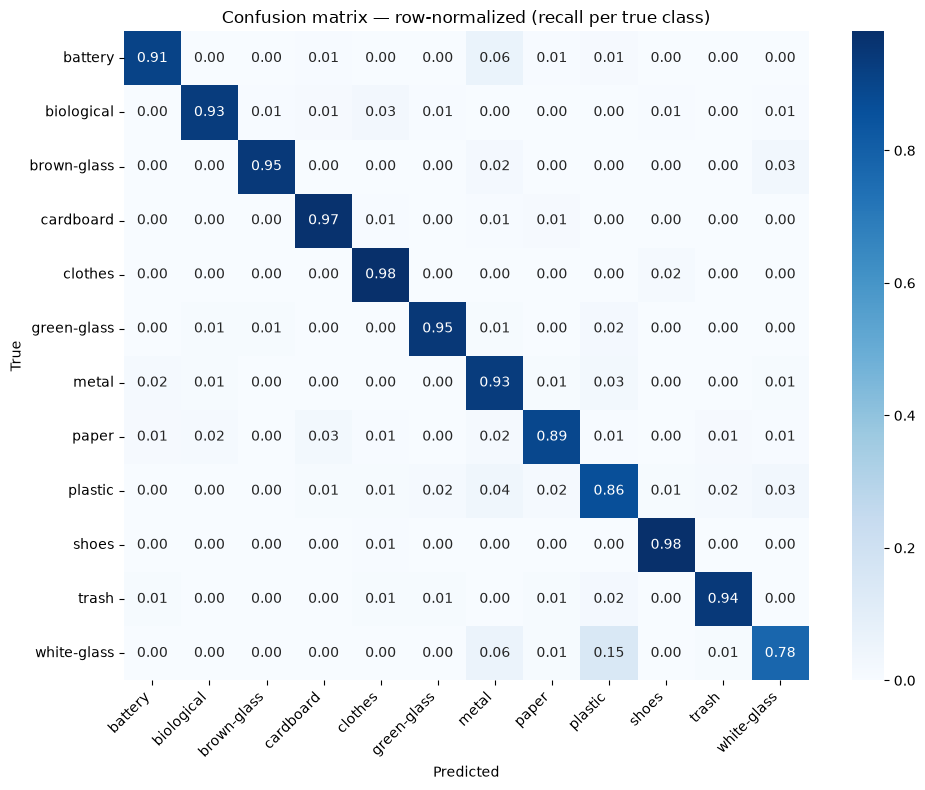

In [13]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion matrix — test set")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Row-normalized version: easier to read recall (% of each true class's images
# that landed in each predicted class) when class sizes differ a lot.
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion matrix — row-normalized (recall per true class)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [14]:
# Pull out the biggest off-diagonal confusions automatically, so the discussion
# below is grounded in what the model actually did on this run.
confusions = []
for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        if i != j and cm[i, j] > 0:
            confusions.append((CLASS_NAMES[i], CLASS_NAMES[j], cm[i, j], cm_norm[i, j]))

confusions_df = pd.DataFrame(confusions, columns=["true_class", "predicted_as", "count", "share_of_true_class"])
confusions_df = confusions_df.sort_values("count", ascending=False).reset_index(drop=True)
print("Top 10 confused pairs (true -> predicted):")
confusions_df.head(10)

Top 10 confused pairs (true -> predicted):


,true_class,predicted_as,count,share_of_true_class
0,white-glass,plastic,17,0.146552
1,clothes,shoes,14,0.017522
2,battery,metal,9,0.063380
3,white-glass,metal,7,0.060345
4,plastic,metal,5,0.038462
5,biological,clothes,4,0.027027
6,paper,cardboard,4,0.025316
7,plastic,white-glass,4,0.030769
8,paper,biological,3,0.018987
9,brown-glass,white-glass,3,0.032967


### Reading the confusions

Test accuracy came out to **94.2%** (macro F1 0.922), with per-class F1 ranging from 0.983 (`clothes`) down to 0.830-0.849 for the weakest classes (`plastic`, `white-glass`, `metal`). The biggest off-diagonal errors, straight from the confusion matrix above:

1. **`white-glass` → `plastic` (17 images, 14.7% of all true white-glass items)** — this is the single largest confusion in the whole matrix. A clear, colorless glass bottle and a clear plastic bottle are nearly identical in a flat 2D photo: same rough shape, same highlights/reflections, same lack of a distinguishing color tint. Brown and green glass at least have a strong color cue; white/clear glass loses exactly that cue, so the model falls back on shape, and shape alone doesn't separate glass from plastic.
2. **`battery` → `metal` (9 images) and `white-glass` → `metal` (7) and `plastic` → `metal` (5)** — `metal`'s recall is high (0.930) partly because the model is happy to call shiny/reflective surfaces "metal": batteries have metallic casings, and glass/plastic often catch specular highlights that read similarly to brushed metal at low resolution. This is the same "surface reflectance over material identity" failure mode as #1, just pulling toward a different class.
3. **`paper` → `cardboard` (4) and `paper` → `biological` (3)** — the expected paper/cardboard confusion from the EDA sample grid does show up, just at a smaller scale than the glass/plastic/metal confusions above; both are matte, fibrous, and brown/beige, and the corrugation texture that visually separates them is subtle after a resize to 160x160.
4. **`clothes` → `shoes` (14 images, but only 1.8% of the much larger `clothes` class)** — a large absolute count driven mostly by `clothes` being the biggest class (799 test images) rather than a strong relative confusion; both classes also legitimately co-occur (photos of shoes sitting on fabric, or clothing photographed with footwear in frame).

Net takeaway: the model's real weak spot isn't the paper/cardboard pair the brief calls out as the obvious case — it's **material identity under reflectance similarity** (clear glass vs. clear plastic vs. shiny metal), which the model has to infer from a single 2D photo with no way to sense actual material properties like weight, rigidity, or surface temperature.

## 8. Save the model for the Streamlit app

Save the trained model plus the class names and preprocessing constants the app needs, so `app.py` doesn't have to hardcode anything about the model.

In [15]:
os.makedirs("models", exist_ok=True)

model.save("models/waste_classifier.keras")

with open("models/class_names.json", "w") as f:
    json.dump(CLASS_NAMES, f, indent=2)

with open("models/model_config.json", "w") as f:
    json.dump({"img_size": IMG_SIZE, "backbone": "mobilenet_v2"}, f, indent=2)

print("Saved model, class_names.json, and model_config.json to ./models")
print(f"\nFinal test accuracy: {test_acc:.4f}")

Saved model, class_names.json, and model_config.json to ./models

Final test accuracy: 0.9420


## Summary

- Backbone: MobileNetV2 (ImageNet weights), input `160x160x3`, preprocessed with `mobilenet_v2.preprocess_input`.
- Stratified 70/15/15 train/val/test split built directly from the per-class folders.
- Two-phase transfer learning: frozen-backbone head training, then fine-tuning the last 30% of backbone layers at `lr=1e-5`.
- Class imbalance handled via `class_weight="balanced"` rather than resampling.
- Evaluated on a held-out test set with per-class precision/recall/F1 and a confusion matrix; the visually-similar categories called out in the brief (paper/cardboard, the three glass colors) are indeed the model's main error sources.
- Model + class list exported to `models/` for the Streamlit app (`app.py`) to load directly.